In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
import seaborn as sns
#Se carga la tabla de la base de datos
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x)else x)

c:\Users\heroj\anaconda3\envs\proyecto_python1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Filtracion de datos por pais y por trabajo especifico
df_DS_ch = df[(df['job_country']== 'Chile') & (df['job_title_short'] == 'Data Scientist')]

In [13]:
df_DS_ch

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
91,Data Scientist,Data Scientist,"Temuco, Chile",via BeBee Chile,Full-time,False,Chile,2023-01-06 14:07:40,False,False,Chile,NaN,NaN,NaN,Talently,"[sql, python, tensorflow, numpy, pandas, excel...","{'analyst_tools': ['excel', 'tableau'], 'libra..."
237,Data Scientist,Data Science Specialist,"Santiago, Chile",via Trabajo.org,Full-time,False,Chile,2023-01-29 13:25:16,False,False,Chile,NaN,NaN,NaN,BairesDev,NaN,NaN
301,Data Scientist,Data Scientist,"Santiago, Chile",via LinkedIn,Full-time,False,Chile,2023-05-17 13:33:57,False,False,Chile,NaN,NaN,NaN,"SMU S.A. (Unimarc, M10, Alvi, y Super10)",NaN,NaN
2500,Data Scientist,Data Scientist,Chile,via BeBee Chile,Full-time,False,Chile,2023-04-16 13:46:46,False,False,Chile,NaN,NaN,NaN,Digital Talents,"[c, python, sql, git]","{'other': ['git'], 'programming': ['c', 'pytho..."
3795,Data Scientist,Científico de datos,"Santiago, Chile",via BeBee Chile,Full-time,False,Chile,2023-06-24 13:33:43,False,False,Chile,NaN,NaN,NaN,Universidad de Chile,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785398,Data Scientist,Data Scientist Llms,"Santiago, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-09-24 06:31:55,False,False,Chile,NaN,NaN,NaN,KLog.co,"[python, sql, aws, pandas, pyspark, airflow, n...","{'cloud': ['aws'], 'libraries': ['pandas', 'py..."
785419,Data Scientist,Data Scientists,"Las Condes, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-08-20 06:30:06,False,False,Chile,NaN,NaN,NaN,Vida Cámara,NaN,NaN
785588,Data Scientist,Data Scientist,"Santiago, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-10-01 06:42:51,False,False,Chile,NaN,NaN,NaN,ANASAC,"[sql, python, r, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
785589,Data Scientist,Científico de Datos,"Huechuraba, Chile","via Trabajo.org - Vacantes De Empleo, Trabajo",Full-time,False,Chile,2023-10-01 06:43:05,False,False,Chile,NaN,NaN,NaN,CHILEXPRESS SA,"[sql, r, spark, hadoop]","{'libraries': ['spark', 'hadoop'], 'programmin..."


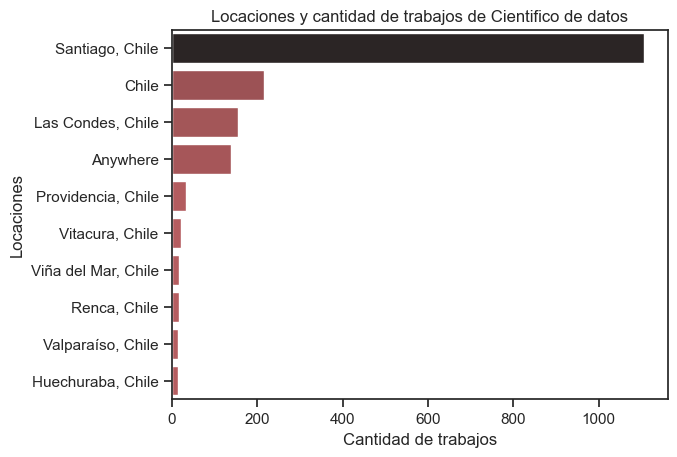

In [ ]:
#Representacion de datos filtrados como grafico de barra horizontal
df_plot = df_DS_ch['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:r_r', legend=False)
plt.title('Locaciones y cantidad de trabajos de Cientifico de datos')
plt.ylabel('Locaciones')
plt.xlabel('Cantidad de trabajos')
plt.show()


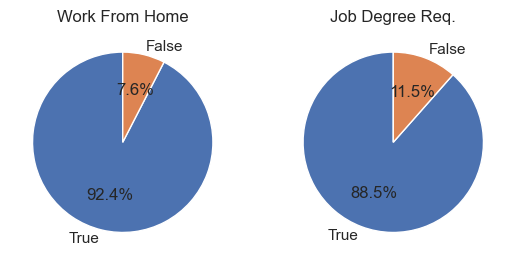

In [ ]:
#Representacion de datos filtrados como grafico circular

fig, ax =plt.subplots(1, 2)
dict_column = {
    'job_work_from_home': 'Work From Home',
    'job_no_degree_mention':'Job Degree Req.'
}
for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DS_ch[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=[True, False])
    ax[i].set_title(title)


plt.show()

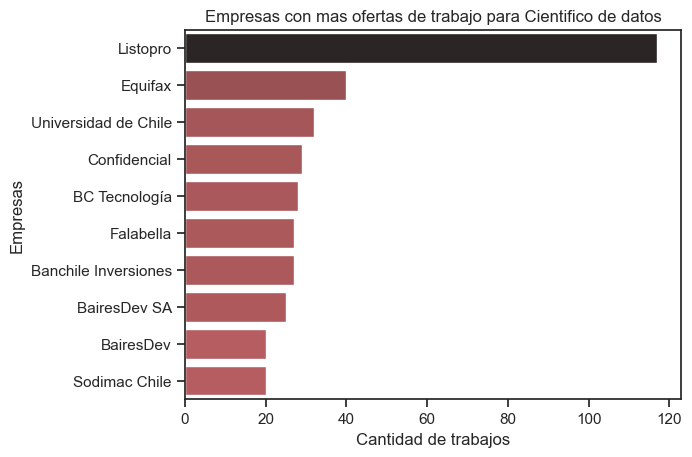

In [22]:
df_plot = df_DS_ch['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:r_r', legend=False)
plt.title('Empresas con mas ofertas de trabajo para Cientifico de datos')
plt.ylabel('Empresas')
plt.xlabel('Cantidad de trabajos')
plt.show()
